# Sentiment Analysis

### OIBSIP Data Analytics — Level 1 — Task 4

## Objective
Build a machine-learning model that classifies Twitter text as **Positive, Negative, or Neutral**.

### Dataset
This notebook is specifically designed for Kaggle's **Twitter and Reddit Sentimental Analysis** dataset, using **`Twitter_Data.csv`**. The Kaggle dataset contains about 163K tweets, with `clean_text` as the tweet text and `category` as the sentiment label: `-1 = Negative`, `0 = Neutral`, and `1 = Positive`. citeturn0search0turn0search1

### Models
- Multinomial Naive Bayes
- Logistic Regression

The notebook evaluates both models using accuracy, precision, recall, F1-score, and confusion matrices.


## 1. Import Libraries


In [10]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
# Install once if required:
# %pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from wordcloud import WordCloud

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

pd.set_option("display.max_colwidth", 150)
sns.set_theme(style="whitegrid")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abid\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abid\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abid\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Load `Twitter_Data.csv`

The Kaggle file uses two relevant columns:

- `clean_text` — cleaned tweet text
- `category` — sentiment label (`-1`, `0`, `1`)

The dataset description confirms these three labels. citeturn0search0turn0search5


In [12]:
df = pd.read_csv(
    "twitter_Data.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())


Dataset loaded successfully!
Dataset shape: (162980, 2)

Columns:
['clean_text', 'category']


,clean_text,category
0,when modi promised âminimum government maximum governanceâ expected him begin the difficult job reforming the state why does take years get ju...,-1.0
1,talk all the nonsense and continue all the drama will vote for modi,0.0
2,what did just say vote for modi welcome bjp told you rahul the main campaigner for modi think modi should just relax,1.0
3,asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now crustal clear what will crass...,1.0
4,answer who among these the most powerful world leader today trump putin modi may,1.0


### Initial inspection

Check data types, missing values, duplicate records, and sentiment labels before modelling.


In [13]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nOriginal sentiment labels:")
print(df["category"].value_counts(dropna=False))


<class 'pandas.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  str    
 1   category    162973 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.5 MB
None

Missing values:
clean_text    4
category      7
dtype: int64

Duplicate rows: 1

Original sentiment labels:
category
 1.0    72250
 0.0    55213
-1.0    35510
 NaN        7
Name: count, dtype: int64


## 3. Prepare the Target Variable

For readability, numeric labels are converted to:

- `-1` → **Negative**
- `0` → **Neutral**
- `1` → **Positive**

Rows with missing text or invalid sentiment labels are removed.


In [14]:
df = df[["clean_text", "category"]].copy()

df = df.dropna(subset=["clean_text", "category"])

df["category"] = pd.to_numeric(df["category"], errors="coerce")
df = df.dropna(subset=["category"])

df["category"] = df["category"].astype(int)

label_map = {
    -1: "negative",
     0: "neutral",
     1: "positive"
}

df["sentiment"] = df["category"].map(label_map)

df = df.dropna(subset=["sentiment"])

print("Clean dataset shape:", df.shape)
display(df[["clean_text", "sentiment"]].head())


Clean dataset shape: (162969, 3)


,clean_text,sentiment
0,when modi promised âminimum government maximum governanceâ expected him begin the difficult job reforming the state why does take years get ju...,negative
1,talk all the nonsense and continue all the drama will vote for modi,neutral
2,what did just say vote for modi welcome bjp told you rahul the main campaigner for modi think modi should just relax,positive
3,asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now crustal clear what will crass...,positive
4,answer who among these the most powerful world leader today trump putin modi may,positive


## 4. Sentiment Distribution

sentiment
negative    35509
neutral     55211
positive    72249
Name: count, dtype: int64


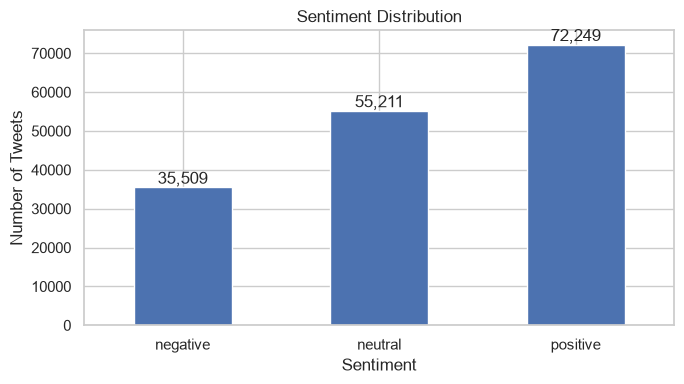

In [15]:
sentiment_order = ["negative", "neutral", "positive"]
sentiment_counts = df["sentiment"].value_counts().reindex(sentiment_order)

print(sentiment_counts)

plt.figure(figsize=(7, 4))
ax = sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)

for i, value in enumerate(sentiment_counts):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


## 5. Text Preprocessing

The preprocessing pipeline performs:

1. Lowercasing
2. URL removal
3. User-mention removal
4. Hashtag symbol removal
5. Punctuation removal
6. Number removal
7. NLTK tokenisation
8. Stopword removal

Important negation words such as **not, no, never, neither, nor** are retained because removing them can change sentiment meaning.


In [16]:
stop_words = set(stopwords.words("english"))
stop_words -= {"not", "no", "never", "neither", "nor"}

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    return " ".join(tokens)

df["cleaned_text"] = df["clean_text"].apply(preprocess_text)

df = df[df["cleaned_text"].str.strip().ne("")].copy()

display(df[["clean_text", "cleaned_text", "sentiment"]].head(10))


,clean_text,cleaned_text,sentiment
0,when modi promised âminimum government maximum governanceâ expected him begin the difficult job reforming the state why does take years get ju...,modi promised government maximum expected begin difficult job reforming state take years get justice state not business exit psus temples,negative
1,talk all the nonsense and continue all the drama will vote for modi,talk nonsense continue drama vote modi,neutral
2,what did just say vote for modi welcome bjp told you rahul the main campaigner for modi think modi should just relax,say vote modi welcome bjp told rahul main campaigner modi think modi relax,positive
3,asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now crustal clear what will crass...,asking supporters prefix chowkidar names modi great service confusion read not crustal clear crass filthy nonsensical see abuses coming chowkidars,positive
4,answer who among these the most powerful world leader today trump putin modi may,answer among powerful world leader today trump putin modi may,positive
5,kiya tho refresh maarkefir comment karo,kiya tho refresh maarkefir comment karo,neutral
6,surat women perform yagna seeks divine grace for narendra modi become again\n,surat women perform yagna seeks divine grace narendra modi become,neutral
7,this comes from cabinet which has scholars like modi smriti and hema time introspect,comes cabinet scholars like modi smriti hema time introspect,neutral
8,with upcoming election india saga going important pair look current modi leads govt elected with deal brexit combination this weekly looks juicy b...,upcoming election india saga going important pair look current modi leads govt elected deal brexit combination weekly looks juicy bears imho,positive
9,gandhi was gay does modi,gandhi gay modi,positive


### Preprocessing comment

The cleaned text contains fewer noisy elements and is more suitable for numerical feature extraction. Because the Kaggle dataset is already described as cleaned, this additional pipeline is intentionally conservative and mainly standardises case, tokens, punctuation, URLs, mentions, and stopwords.


## 6. Train/Test Split — 80/20

The data is divided into **80% training** and **20% testing**. Stratification preserves approximately the same sentiment proportions in both sets.


In [17]:
X = df["cleaned_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 130310
Testing samples : 32578


## 7. TF-IDF Feature Extraction

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts text into numerical features that machine-learning algorithms can use.

TF-IDF gives greater weight to words that are informative within a document but less common across the whole collection. Very common words receive relatively less importance. `TfidfVectorizer` combines token counting and TF-IDF weighting in one transformer. citeturn0search2turn0search11

This project uses **unigrams and bigrams** so the model can learn both individual words and short phrases.


In [18]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=30000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)
print("Number of features  :", len(tfidf.get_feature_names_out()))


Training TF-IDF shape: (130310, 30000)
Testing TF-IDF shape : (32578, 30000)
Number of features  : 30000


**Comment:** The vectorizer is fitted only on the training text. The test text is transformed using the already-fitted vectorizer, which avoids test-set information leaking into training.


## 8. Model 1 — Multinomial Naive Bayes


In [19]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    nb_pred,
    labels=["negative", "neutral", "positive"],
    digits=4,
    zero_division=0
))


              precision    recall  f1-score   support

    negative     0.8296    0.4640    0.5951      7102
     neutral     0.8173    0.6681    0.7352     11027
    positive     0.6673    0.9048    0.7681     14449

    accuracy                         0.7286     32578
   macro avg     0.7714    0.6790    0.6995     32578
weighted avg     0.7534    0.7286    0.7193     32578



**Comment:** Naive Bayes provides a fast and strong baseline for text classification. Its class-wise F1-scores show which sentiment categories it handles well and which require improvement.


## 9. Model 2 — Logistic Regression


In [20]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    lr_pred,
    labels=["negative", "neutral", "positive"],
    digits=4,
    zero_division=0
))


              precision    recall  f1-score   support

    negative     0.8852    0.7749    0.8263      7102
     neutral     0.8566    0.9693    0.9095     11027
    positive     0.9248    0.8886    0.9063     14449

    accuracy                         0.8911     32578
   macro avg     0.8889    0.8776    0.8807     32578
weighted avg     0.8931    0.8911    0.8900     32578



**Comment:** Logistic Regression is a strong linear classifier for sparse TF-IDF features. Its performance can be compared fairly with Naive Bayes because both models use exactly the same training and testing features.


## 10. Model Evaluation Comparison

The project reports:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score

**F1-score is the main comparison metric** because it balances precision and recall and is more informative than accuracy when the classes are not perfectly balanced.


In [21]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred, average="weighted", zero_division=0),
        precision_score(y_test, lr_pred, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, nb_pred, average="weighted", zero_division=0),
        recall_score(y_test, lr_pred, average="weighted", zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, nb_pred, average="weighted", zero_division=0),
        f1_score(y_test, lr_pred, average="weighted", zero_division=0)
    ]
})

display(results.round(4))

best_model_name = results.loc[
    results["F1-Score"].idxmax(), "Model"
]

best_pred = lr_pred if best_model_name == "Logistic Regression" else nb_pred

print("Best model based on weighted F1-score:", best_model_name)


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7286,0.7534,0.7286,0.7193
1,Logistic Regression,0.8911,0.8931,0.8911,0.8900


Best model based on weighted F1-score: Logistic Regression


### Evaluation comment

The model with the higher weighted F1-score is selected as the better overall classifier. Do not claim that Naive Bayes or Logistic Regression is best until this cell has been executed on the actual dataset.


## 11. Confusion Matrices

A confusion matrix shows correct predictions on the diagonal and misclassifications outside the diagonal.


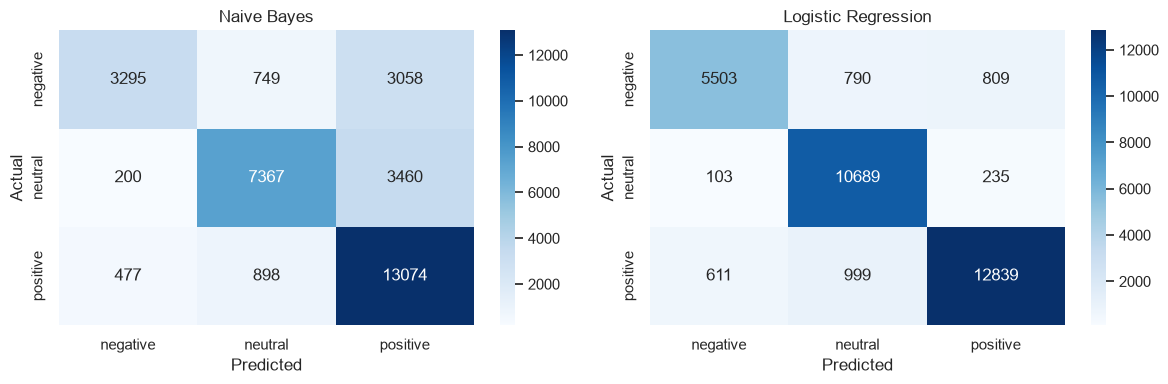

In [22]:
labels = ["negative", "neutral", "positive"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, title in zip(
    axes,
    [nb_pred, lr_pred],
    ["Naive Bayes", "Logistic Regression"]
):
    cm = confusion_matrix(y_test, pred, labels=labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


**Comment:** Strong diagonal values indicate correct classification. Large off-diagonal values show which sentiment pairs are difficult to distinguish. Neutral tweets can be particularly challenging because they may contain little explicit sentiment.


## 12. WordCloud — Positive Sentiment


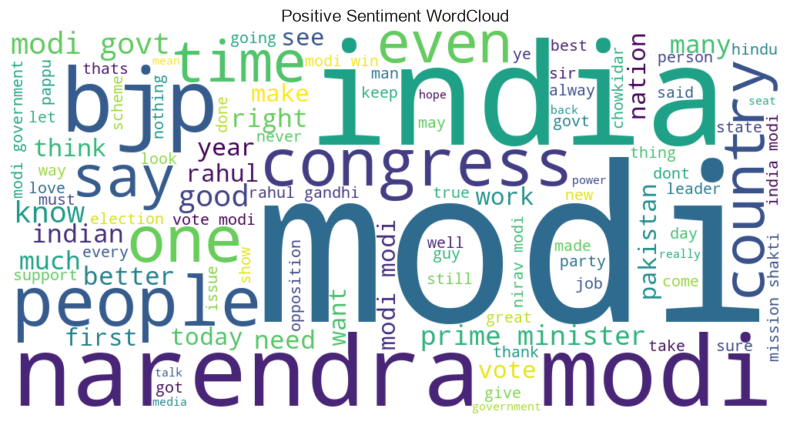

In [23]:
positive_text = " ".join(
    df.loc[df["sentiment"] == "positive", "cleaned_text"]
)

positive_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 5))
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Sentiment WordCloud")
plt.show()


**Comment:** The Positive WordCloud highlights frequently occurring terms among positive tweets. Frequency does not necessarily mean a word is exclusively positive.


## 13. WordCloud — Negative Sentiment


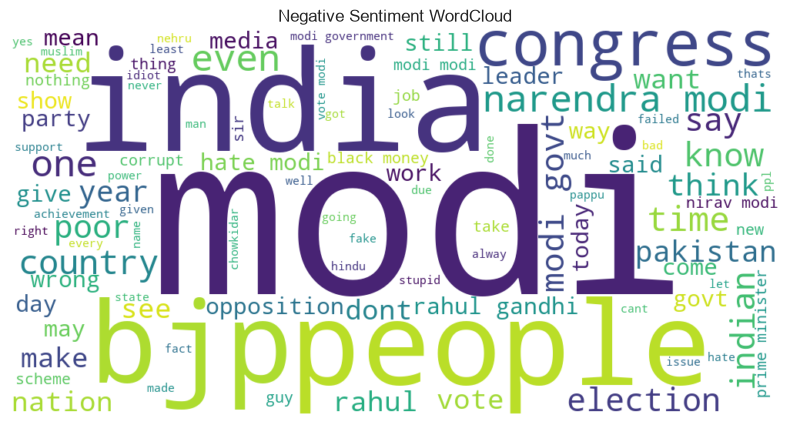

In [24]:
negative_text = " ".join(
    df.loc[df["sentiment"] == "negative", "cleaned_text"]
)

negative_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 5))
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Sentiment WordCloud")
plt.show()


**Comment:** The Negative WordCloud provides a qualitative view of common vocabulary associated with negative tweets.


## 14. WordCloud — Neutral Sentiment


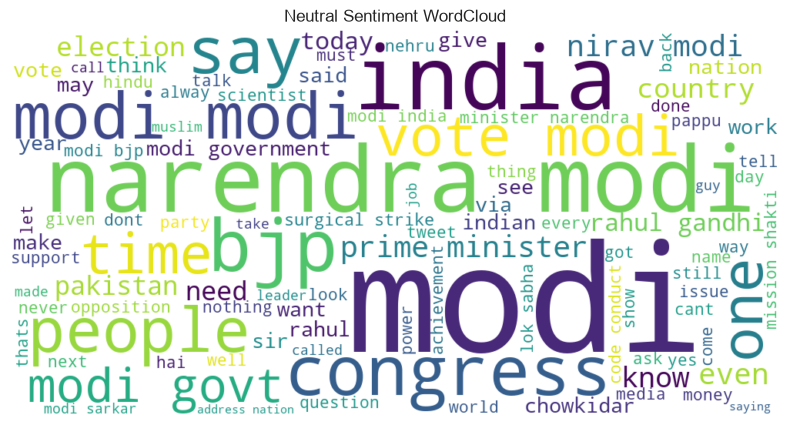

In [25]:
neutral_text = " ".join(
    df.loc[df["sentiment"] == "neutral", "cleaned_text"]
)

neutral_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(neutral_text)

plt.figure(figsize=(12, 5))
plt.imshow(neutral_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral Sentiment WordCloud")
plt.show()


**Comment:** Neutral tweets often contain factual or informational terms. The WordCloud helps identify common topics and vocabulary within this class.


## 15. Error Analysis — 5 Misclassified Examples

The following examples use whichever model achieved the higher weighted F1-score.


In [26]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": best_pred
})

errors = error_df[
    error_df["actual"] != error_df["predicted"]
].head(5).copy()

display(errors)


,text,actual,predicted
0,jyoti patel uganda praises modis efforts swacch bharat abhiyan govts astounding efforts build record roads highways past five years pradhan mantri...,positive,negative
1,half dick deserves thrown hate modi talks respectful position women pissful community famous abusing women via halala triple talaqmodi stopped unw...,positive,negative
25,success drdo today made proudthey shld congratulated nehrupolicy encouragin research front line areas bearin fruits modi creatd suspense made dram...,negative,positive
40,respected narendra modi sir leaving vinayaka homes society ujala circle ahmedabad builder keval mehta cheated society members not completion pendi...,positive,neutral
43,thats difference average citizen called bhakts bhakts mired modi cult dont want come bhakti read dont believe,negative,neutral


### Why can these examples be misclassified?

After inspecting the five examples above, common causes may include:

1. **Sarcasm** — the literal words may suggest the opposite sentiment.
2. **Mixed sentiment** — a tweet can contain both praise and criticism.
3. **Context dependence** — a word can have different meanings in different topics.
4. **Short or factual text** — neutral tweets may contain too little sentiment information.
5. **Social-media language** — abbreviations, slang, misspellings, hashtags, and informal expressions can confuse a simple TF-IDF model.

Use the displayed examples to connect the observed errors to these causes rather than assuming every error has the same reason.


## 16. Conclusion

This project implements a complete sentiment-analysis workflow using the `Twitter_Data.csv` dataset:

- Dataset inspection and class distribution
- Text preprocessing
- 80/20 train-test split
- TF-IDF feature extraction
- Multinomial Naive Bayes
- Logistic Regression
- Accuracy, precision, recall, and F1-score
- Confusion matrices
- Sentiment-specific WordClouds
- Five-example error analysis

### Best model
The model with the **highest weighted F1-score** is selected automatically after execution.

### Real-world applications
The final classifier could be used for:

- Customer feedback monitoring
- Social-media opinion tracking
- Brand reputation analysis
- Product/service review analysis
- Complaint and satisfaction monitoring

### Limitation
Twitter sentiment is highly context-dependent. Sarcasm, mixed opinions, slang, changing vocabulary, and political context can cause errors. Therefore, a production system should be monitored and periodically retrained.


## 17. References

- Kaggle — Twitter and Reddit Sentimental Analysis Dataset: https://www.kaggle.com/datasets/cosmos98/twitter-and-reddit-sentimental-analysis-dataset
- scikit-learn — TF-IDF / text feature extraction: https://scikit-learn.org/stable/modules/feature_extraction.html
- NLTK: https://www.nltk.org/
- TextBlob: https://textblob.readthedocs.io/en/latest/quickstart.html#sentiment-analysis
